# Full-scale pipeline — validated modeling approach

This notebook runs the **full 40M-row Avazu dataset** with the modeling approach we
validated for stability and generalization. It is separate from `eda.ipynb` (which stays
small/fast) because **Run All here takes ~35-40 minutes** (includes a tested-but-not-adopted
target encoding comparison in section 7, and a calibration check in section 8).

Design choices, and why:
- **Time-based split, not random.** Data spans days 21-30. We train on days 21-28,
  validate (for early stopping / hyperparameter choice) on day 29, and test on **day 30,
  touched exactly once at the very end.** A random split can hide overfitting that a
  true future-day split reveals — closer to how the model would actually be used.
- **Leak-safe frequency encoding** for high-cardinality columns (`site_id`, `app_id`,
  `device_model`, `device_id`, `device_ip`). Frequency maps are fit on the training days
  ONLY, then applied (not re-fit) to validation/test — so no information from val/test
  leaks into the features.
- **Early stopping, not a fixed tree count**, so the number of boosting rounds is chosen
  by generalization performance on the validation day, not guessed.
- **Hyperparameter search on a subsample** (3M train / 1M val rows) for speed, then one
  full-scale confirmation run with the winning config.
- We report **train vs. val vs. test metrics side by side** so any overfitting gap is
  visible, not hidden.
- **Section 1b checks the hour-of-day pattern honestly**: a reference-line chart (not a
  misleadingly truncated axis) and a scatter plot (the correct chart for a correlation
  claim, not two overlaid line series) checking whether the pattern is really about time,
  or partly about which site categories run at which hour.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay
import lightgbm as lgb

pd.set_option('display.max_columns', 50)

LOW_CARD = ['C1', 'banner_pos', 'site_category', 'app_category',
            'device_type', 'device_conn_type', 'hour_of_day']
HIGH_CARD = ['site_id', 'app_id', 'device_model', 'device_id', 'device_ip']

## 1. Load full data + time-based split

In [2]:
t_start = time.time()

df = pd.read_csv('../data/train.csv')
df['hour_of_day'] = (df['hour'] % 100).astype(int)
df['day'] = (df['hour'] // 100) % 100
print(f'loaded {len(df):,} rows in {time.time()-t_start:.1f}s')

dev_train = df[df['day'] <= 28].copy()   # days 21-28: training
val = df[df['day'] == 29].copy()          # day 29: early stopping / hyperparameter choice
test = df[df['day'] == 30].copy()         # day 30: held out, touched once at the end
print(f'dev_train: {len(dev_train):,}  val: {len(val):,}  test: {len(test):,}')
print('\nPer-day click rate (checking the split is representative, not a fluke day):')
print(df.groupby('day')['click'].mean())

loaded 40,428,967 rows in 35.4s


dev_train: 32,377,421  val: 3,832,608  test: 4,218,938

Per-day click rate (checking the split is representative, not a fluke day):


day
21    0.174198
22    0.157167
23    0.182190
24    0.174716
25    0.182402
26    0.183049
27    0.181594
28    0.152182
29    0.156562
30    0.169281
Name: click, dtype: float64


## 1b. Reading the hour-of-day pattern carefully

Click rate visibly varies by hour. Two things worth checking honestly before using that in
the presentation:

1. **Is it real, or just a truncated-axis illusion?** We plot it with a reference line at
   the 24h average, so the chart doesn't oversell a modest swing.
2. **Is it really about "time," or partly about *what inventory runs* at that hour?** We
   check whether the mix of top site categories shifts by hour, and whether it correlates
   with click rate — using a **scatter plot** (one dot per hour), which is the correct chart
   for a correlation claim, not two overlaid line charts (which can visually oversell or
   hide a relationship depending on how the two series happen to be scaled).

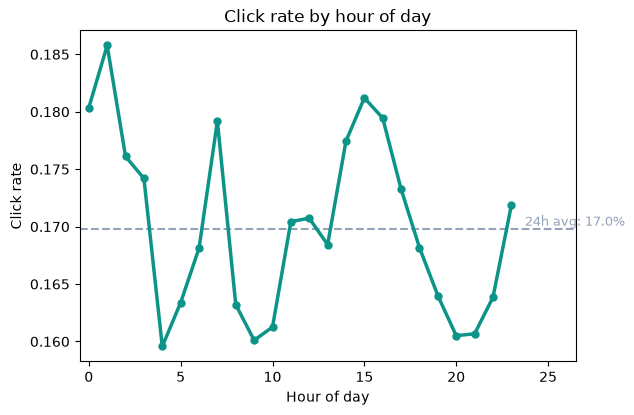

Range: 16.0% - 18.6%  (24h average: 17.0%)


In [3]:
ctr_by_hour = df.groupby('hour_of_day')['click'].mean()
overall_ctr = df['click'].mean()

fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.axhline(overall_ctr, color='#94a3b8', linestyle='--', linewidth=1.5)
ax.text(23.3, overall_ctr, f'  24h avg: {overall_ctr:.1%}', va='bottom', ha='left', fontsize=9.5, color='#94a3b8')
ax.plot(ctr_by_hour.index, ctr_by_hour.values, marker='o', color='#0d9488', linewidth=2.5, markersize=5)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Click rate')
ax.set_title('Click rate by hour of day')
ax.set_xlim(-0.5, 26.5)
plt.show()

print(f'Range: {ctr_by_hour.min():.1%} - {ctr_by_hour.max():.1%}  (24h average: {overall_ctr:.1%})')

Pearson correlation (click rate vs. top-3 site_category share, by hour): r=-0.527  p=0.0081


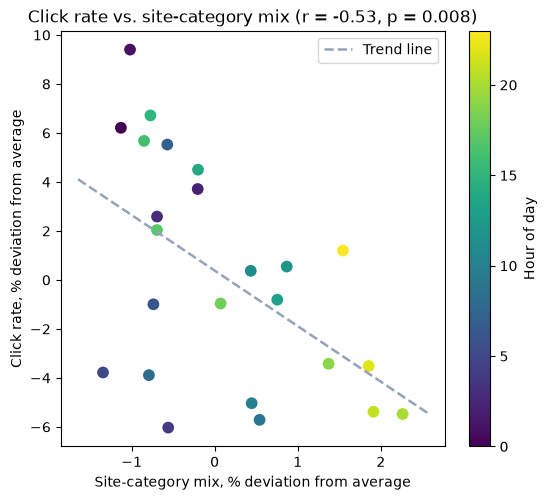


r² = 0.28 — the trend line explains ~28% of the hourly variance in click rate;
most of the pattern is still genuinely about time, not just inventory mix.


In [4]:
from scipy.stats import pearsonr, linregress

top_cats = df['site_category'].value_counts().head(3).index
mix_by_hour = df.groupby('hour_of_day')['site_category'].apply(lambda s: s.isin(top_cats).mean())
overall_mix = df['site_category'].isin(top_cats).mean()

ctr_dev = (ctr_by_hour / overall_ctr - 1) * 100
mix_dev = (mix_by_hour / overall_mix - 1) * 100

r, p = pearsonr(mix_dev.values, ctr_dev.values)
slope, intercept, _, _, _ = linregress(mix_dev.values, ctr_dev.values)
print(f'Pearson correlation (click rate vs. top-3 site_category share, by hour): r={r:.3f}  p={p:.4f}')

fig, ax = plt.subplots(figsize=(6.2, 5.4))
xs = np.linspace(mix_dev.min() - 0.3, mix_dev.max() + 0.3, 10)
ax.plot(xs, intercept + slope * xs, linestyle='--', color='#94a3b8', linewidth=1.8, label='Trend line')
sc = ax.scatter(mix_dev.values, ctr_dev.values, c=mix_dev.index, cmap='viridis', s=90, edgecolor='white', linewidth=1)
fig.colorbar(sc, ax=ax, label='Hour of day')
ax.set_xlabel('Site-category mix, % deviation from average')
ax.set_ylabel('Click rate, % deviation from average')
ax.set_title(f'Click rate vs. site-category mix (r = {r:.2f}, p = {p:.3f})')
ax.legend(loc='upper right')
plt.show()

print(f'\nr² = {r**2:.2f} — the trend line explains ~{r**2:.0%} of the hourly variance in click rate;')
print('most of the pattern is still genuinely about time, not just inventory mix.')

### Click volume vs. click rate — two different questions

The chart above answers "if an ad is shown this hour, how likely is it to be clicked"
(click **rate** — relatively flat, 16-18.6%). That's a different question from "how many
actual clicks happen this hour" (click **volume**) — which mostly tracks how many people are
online at all, not how click-happy they are. Worth showing both so the two don't get
conflated: a business decision about *when to have capacity ready* cares about volume; a
decision about *which impression is worth showing an ad to* cares about rate.

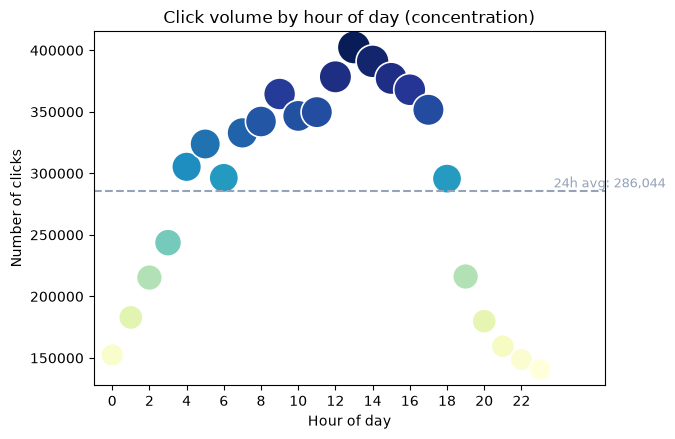

Peak hour: 13 with 402,344 clicks
Lowest hour: 23 with 140,699 clicks
Peak is 2.9x the lowest hour (vs. only ~1.16x for click RATE — volume swings far more than rate does)


In [5]:
clicks_by_hour = df[df['click'] == 1].groupby('hour_of_day').size()
avg_clicks = clicks_by_hour.mean()

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.axhline(avg_clicks, color='#94a3b8', linestyle='--', linewidth=1.5)
ax.text(23.3, avg_clicks, f'  24h avg: {avg_clicks:,.0f}', va='bottom', ha='left', fontsize=9.5, color='#94a3b8')

sizes = (clicks_by_hour.values / clicks_by_hour.max()) * 500 + 80
sc = ax.scatter(clicks_by_hour.index, clicks_by_hour.values, s=sizes, c=clicks_by_hour.values,
                 cmap='YlGnBu', edgecolor='white', linewidth=1.2, vmin=clicks_by_hour.min())
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of clicks')
ax.set_title('Click volume by hour of day (concentration)')
ax.set_xlim(-1, 26.5)
ax.set_xticks(range(0, 24, 2))
plt.show()

print(f'Peak hour: {clicks_by_hour.idxmax()} with {clicks_by_hour.max():,} clicks')
print(f'Lowest hour: {clicks_by_hour.idxmin()} with {clicks_by_hour.min():,} clicks')
print(f'Peak is {clicks_by_hour.max() / clicks_by_hour.min():.1f}x the lowest hour '
      f'(vs. only ~1.16x for click RATE — volume swings far more than rate does)')

## 2. Leak-safe frequency encoding

High-cardinality columns like `device_ip` can't be one-hot encoded, but their raw ID
values are meaningless to a model anyway. Frequency encoding ("how often has this ID been
seen?") gives the model a useful numeric signal without leaking the label. The frequency
map is fit on `dev_train` only.

In [6]:
freq_maps = {col: dev_train[col].value_counts() for col in HIGH_CARD}

def apply_freq(frame):
    out = frame.copy()
    for col in HIGH_CARD:
        out[col + '_freq'] = out[col].map(freq_maps[col]).fillna(0).astype(int)
    return out

dev_train = apply_freq(dev_train)
val = apply_freq(val)
test = apply_freq(test)
freq_cols = [c + '_freq' for c in HIGH_CARD]
print('frequency-encoded columns:', freq_cols)

frequency-encoded columns: ['site_id_freq', 'app_id_freq', 'device_model_freq', 'device_id_freq', 'device_ip_freq']


## 3. Baseline

Always predict the training click rate. Evaluated on the untouched test day, for a fair
comparison with the tuned models below.

In [7]:
baseline_rate = dev_train['click'].mean()
baseline_pred = np.full(len(test), baseline_rate)
print(f'Baseline (train click rate {baseline_rate:.4f}) on test day 30:')
print(f'  AUC: 0.500 (constant prediction cannot rank)')
print(f'  log-loss: {log_loss(test["click"], baseline_pred):.4f}')

Baseline (train click rate 0.1714) on test day 30:
  AUC: 0.500 (constant prediction cannot rank)


  log-loss: 0.4548


## 4. Logistic Regression — tuned, stable low-variance baseline

Search `C` on a subsample first (fast), then confirm at full scale.

In [8]:
def make_xy_logreg(frame):
    X = frame[LOW_CARD].astype(str).copy()
    for c in freq_cols:
        X[c] = frame[c].values
    y = frame['click'].values
    return X, y

X_dev, y_dev = make_xy_logreg(dev_train)
X_val, y_val = make_xy_logreg(val)
X_test, y_test = make_xy_logreg(test)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), LOW_CARD),
    ('freq', StandardScaler(with_mean=False), freq_cols),
])

rng = np.random.RandomState(42)
sub_idx = rng.choice(len(X_dev), size=min(3_000_000, len(X_dev)), replace=False)
X_dev_sub, y_dev_sub = X_dev.iloc[sub_idx], y_dev[sub_idx]
val_sub_idx = rng.choice(len(X_val), size=min(1_000_000, len(X_val)), replace=False)
X_val_sub, y_val_sub = X_val.iloc[val_sub_idx], y_val[val_sub_idx]

Xt_dev_sub = preprocess.fit_transform(X_dev_sub)
Xt_val_sub = preprocess.transform(X_val_sub)

print('C search on 3M-row subsample:')
c_results = []
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=300, solver='lbfgs')
    clf.fit(Xt_dev_sub, y_dev_sub)
    val_auc = roc_auc_score(y_val_sub, clf.predict_proba(Xt_val_sub)[:, 1])
    print(f'  C={C}: val_auc={val_auc:.4f}')
    c_results.append((val_auc, C))

best_C = max(c_results)[1]
print(f'\nBest C: {best_C}')

C search on 3M-row subsample:


  C=0.001: val_auc=0.6305


  C=0.01: val_auc=0.6322


  C=0.1: val_auc=0.6325


  C=1.0: val_auc=0.6324


  C=10.0: val_auc=0.6325

Best C: 0.1


In [9]:
t0 = time.time()
Xt_dev = preprocess.fit_transform(X_dev)
Xt_val = preprocess.transform(X_val)
Xt_test = preprocess.transform(X_test)

logreg_final = LogisticRegression(C=best_C, max_iter=300, solver='lbfgs')
logreg_final.fit(Xt_dev, y_dev)
print(f'full-scale LogReg fit time: {time.time()-t0:.1f}s')

proba_lr_train = logreg_final.predict_proba(Xt_dev)[:, 1]
proba_lr_val = logreg_final.predict_proba(Xt_val)[:, 1]
proba_lr_test = logreg_final.predict_proba(Xt_test)[:, 1]

print('\nLogReg — train/val/test:')
print(f'  Train (d21-28): AUC={roc_auc_score(y_dev, proba_lr_train):.4f}  logloss={log_loss(y_dev, proba_lr_train):.4f}')
print(f'  Val   (d29):    AUC={roc_auc_score(y_val, proba_lr_val):.4f}  logloss={log_loss(y_val, proba_lr_val):.4f}')
print(f'  Test  (d30):    AUC={roc_auc_score(y_test, proba_lr_test):.4f}  logloss={log_loss(y_test, proba_lr_test):.4f}')
print(f'  Train-Test AUC gap: {roc_auc_score(y_dev, proba_lr_train) - roc_auc_score(y_test, proba_lr_test):.4f}')

full-scale LogReg fit time: 265.9s



LogReg — train/val/test:


  Train (d21-28): AUC=0.6269  logloss=0.4428


  Val   (d29):    AUC=0.6322  logloss=0.4195


  Test  (d30):    AUC=0.6509  logloss=0.4371


  Train-Test AUC gap: -0.0240


## 5. LightGBM — tuned + early-stopped

Search hyperparameters on a subsample with early stopping against the validation day, then
run one full-scale confirmation with the winning config. Note: evaluation during training
uses the **validation set only** — evaluating AUC on the full 32M-row training set every
boosting round would be prohibitively slow for no benefit; train-set metrics are computed
once after fitting completes.

In [10]:
def make_xy_lgb(frame):
    X = frame[LOW_CARD].astype(str).astype('category').copy()
    for c in freq_cols:
        X[c] = frame[c].values
    y = frame['click'].values
    return X, y

X_dev_lgb, y_dev_lgb = make_xy_lgb(dev_train)
X_val_lgb, y_val_lgb = make_xy_lgb(val)
X_test_lgb, y_test_lgb = make_xy_lgb(test)

X_dev_sub_lgb, y_dev_sub_lgb = X_dev_lgb.iloc[sub_idx], y_dev_lgb[sub_idx]
X_val_sub_lgb, y_val_sub_lgb = X_val_lgb.iloc[val_sub_idx], y_val_lgb[val_sub_idx]

param_grid = [
    dict(num_leaves=31, learning_rate=0.05, min_child_samples=20, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0, colsample_bytree=1.0),
    dict(num_leaves=63, learning_rate=0.05, min_child_samples=50, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=31, learning_rate=0.03, min_child_samples=100, reg_alpha=0.5, reg_lambda=0.5, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=15, learning_rate=0.05, min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8),
    dict(num_leaves=63, learning_rate=0.1, min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0, subsample=0.7, colsample_bytree=0.7),
]

print('Hyperparameter search (3M-row subsample, early stopping):')
lgb_results = []
for i, params in enumerate(param_grid):
    t0 = time.time()
    model = lgb.LGBMClassifier(n_estimators=800, random_state=42, verbose=-1, **params)
    model.fit(
        X_dev_sub_lgb, y_dev_sub_lgb,
        eval_set=[(X_val_sub_lgb, y_val_sub_lgb)],
        eval_names=['val'],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )
    train_auc = roc_auc_score(y_dev_sub_lgb, model.predict_proba(X_dev_sub_lgb)[:, 1])
    val_auc = roc_auc_score(y_val_sub_lgb, model.predict_proba(X_val_sub_lgb)[:, 1])
    print(f'  [{i}] {params}')
    print(f'      best_iter={model.best_iteration_}  train_auc={train_auc:.4f}  val_auc={val_auc:.4f}  gap={train_auc-val_auc:.4f}  ({time.time()-t0:.1f}s)')
    lgb_results.append((val_auc, train_auc - val_auc, params))

lgb_results.sort(key=lambda r: (-r[0], r[1]))
best_val_auc, best_gap, best_params = lgb_results[0]
print(f'\nBest config (val AUC, tie-break smallest gap): {best_params}')

Hyperparameter search (3M-row subsample, early stopping):


  [0] {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'colsample_bytree': 1.0}
      best_iter=800  train_auc=0.7475  val_auc=0.7277  gap=0.0197  (59.0s)


  [1] {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=800  train_auc=0.7552  val_auc=0.7295  gap=0.0257  (74.1s)


  [2] {'num_leaves': 31, 'learning_rate': 0.03, 'min_child_samples': 100, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=800  train_auc=0.7431  val_auc=0.7266  gap=0.0165  (70.6s)


  [3] {'num_leaves': 15, 'learning_rate': 0.05, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8}
      best_iter=799  train_auc=0.7401  val_auc=0.7251  gap=0.0150  (54.4s)


  [4] {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'colsample_bytree': 0.7}
      best_iter=550  train_auc=0.7573  val_auc=0.7300  gap=0.0273  (54.8s)

Best config (val AUC, tie-break smallest gap): {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'colsample_bytree': 0.7}


In [11]:
t0 = time.time()
lgb_final = lgb.LGBMClassifier(n_estimators=1200, random_state=42, verbose=-1, **best_params)
lgb_final.fit(
    X_dev_lgb, y_dev_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    eval_names=['val'],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False), lgb.log_evaluation(period=100)],
)
print(f'full-scale LightGBM fit time: {time.time()-t0:.1f}s  best_iteration={lgb_final.best_iteration_}')

proba_lgb_train = lgb_final.predict_proba(X_dev_lgb)[:, 1]
proba_lgb_val = lgb_final.predict_proba(X_val_lgb)[:, 1]
proba_lgb_test = lgb_final.predict_proba(X_test_lgb)[:, 1]

print('\nLightGBM — train/val/test:')
print(f'  Train (d21-28): AUC={roc_auc_score(y_dev_lgb, proba_lgb_train):.4f}  logloss={log_loss(y_dev_lgb, proba_lgb_train):.4f}')
print(f'  Val   (d29):    AUC={roc_auc_score(y_val_lgb, proba_lgb_val):.4f}  logloss={log_loss(y_val_lgb, proba_lgb_val):.4f}')
print(f'  Test  (d30):    AUC={roc_auc_score(y_test_lgb, proba_lgb_test):.4f}  logloss={log_loss(y_test_lgb, proba_lgb_test):.4f}')
print(f'  Train-Test AUC gap: {roc_auc_score(y_dev_lgb, proba_lgb_train) - roc_auc_score(y_test_lgb, proba_lgb_test):.4f}  (small = not overfit)')

[100]	val's auc: 0.724989	val's binary_logloss: 0.391249


[200]	val's auc: 0.728555	val's binary_logloss: 0.389355


[300]	val's auc: 0.730228	val's binary_logloss: 0.388511


[400]	val's auc: 0.730865	val's binary_logloss: 0.388233


[500]	val's auc: 0.731431	val's binary_logloss: 0.387998


...


LightGBM — train/val/test:


  Train (d21-28): AUC=0.7545  logloss=0.3959


  Val   (d29):    AUC=0.7327  logloss=0.3874


  Test  (d30):    AUC=0.7278  logloss=0.4085


  Train-Test AUC gap: 0.0267  (small = not overfit)


## 6. Final comparison & overfitting diagnostic

All numbers below are on **day 30**, never used for tuning or early stopping.

In [12]:
summary = pd.DataFrame([
    {'model': 'Baseline', 'train_auc': 0.500, 'test_auc': 0.500,
     'test_logloss': log_loss(test['click'], baseline_pred), 'train_test_auc_gap': 0.0},
    {'model': 'Logistic Regression', 'train_auc': roc_auc_score(y_dev, proba_lr_train),
     'test_auc': roc_auc_score(y_test, proba_lr_test), 'test_logloss': log_loss(y_test, proba_lr_test),
     'train_test_auc_gap': roc_auc_score(y_dev, proba_lr_train) - roc_auc_score(y_test, proba_lr_test)},
    {'model': 'LightGBM', 'train_auc': roc_auc_score(y_dev_lgb, proba_lgb_train),
     'test_auc': roc_auc_score(y_test_lgb, proba_lgb_test), 'test_logloss': log_loss(y_test_lgb, proba_lgb_test),
     'train_test_auc_gap': roc_auc_score(y_dev_lgb, proba_lgb_train) - roc_auc_score(y_test_lgb, proba_lgb_test)},
])
summary

,model,train_auc,test_auc,test_logloss,train_test_auc_gap
0,Baseline,0.500000,0.500000,0.454760,0.000000
1,Logistic Regression,0.626881,0.650863,0.437144,-0.023982
2,LightGBM,0.754486,0.727778,0.408531,0.026707


/var/folders/1p/cjg33chj2892zx0g0nzb3p580000gs/T/ipykernel_37237/1636064655.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1], 'k--', color='#94a3b8', label='Random guessing (AUC = 0.50)')


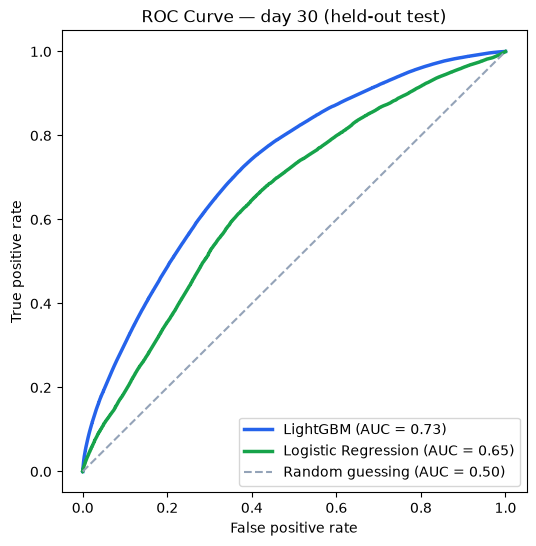

In [13]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr_test)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test_lgb, proba_lgb_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lgb, tpr_lgb, color='#2563eb', linewidth=2.5,
        label=f'LightGBM (AUC = {roc_auc_score(y_test_lgb, proba_lgb_test):.2f})')
ax.plot(fpr_lr, tpr_lr, color='#16a34a', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc_score(y_test, proba_lr_test):.2f})')
ax.plot([0, 1], [0, 1], 'k--', color='#94a3b8', label='Random guessing (AUC = 0.50)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC Curve — day 30 (held-out test)')
ax.legend(loc='lower right')
plt.show()

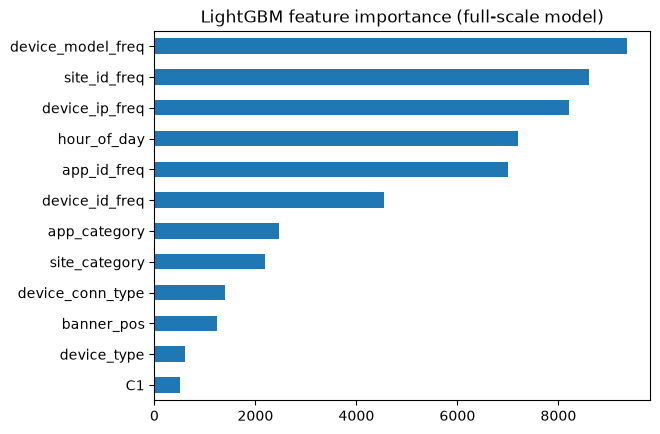

In [14]:
feature_cols = LOW_CARD + freq_cols
importances = pd.Series(lgb_final.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', title='LightGBM feature importance (full-scale model)')
plt.show()

## 7. Target encoding — tested alternative (not adopted)

Frequency encoding (above) is the encoding used for the primary model. We also tested
**cross-fitted target encoding** as an alternative for the same high-cardinality columns,
to see whether it's worth the added complexity.

Target encoding replaces each ID with the (smoothed) average click rate for that ID,
instead of just its frequency — a much more direct signal, but a classic leakage trap if
done naively (encoding a row using stats computed *including that row's own label*).

Leak-safety here:
- Within `dev_train` (the data the stats are computed FROM), we use **5-fold cross-fitting**:
  each row's encoded value comes from a target-mean computed on the *other* folds only.
- For `val`/`test` (already held out in time), we use target-mean stats fit on ALL of
  `dev_train` — no cross-fitting needed since they never contribute to the stats.
- All stats use Bayesian smoothing toward the global mean, weighted by category count, so
  rare/rare-ish IDs don't get noisy estimates.

**Gotcha we hit:** early-stopping on AUC alone stopped training after just ~6-100 rounds,
because AUC (ranking) saturates almost immediately with target-encoded features — but
log-loss (calibration) kept improving for longer. Early-stopping on `binary_logloss`
instead fixed this.

In [15]:
from sklearn.model_selection import KFold

SMOOTHING = 20
global_mean = dev_train['click'].mean()

for col in HIGH_CARD:
    oof = np.full(len(dev_train), global_mean)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    dev_reset = dev_train.reset_index(drop=True)
    for fold_train_idx, fold_hold_idx in kf.split(dev_reset):
        stats = dev_reset.iloc[fold_train_idx].groupby(col)['click'].agg(['mean', 'count'])
        fold_gm = dev_reset.iloc[fold_train_idx]['click'].mean()
        fold_map = (stats['count'] * stats['mean'] + SMOOTHING * fold_gm) / (stats['count'] + SMOOTHING)
        oof[fold_hold_idx] = dev_reset.iloc[fold_hold_idx][col].map(fold_map).fillna(fold_gm).values
    dev_train[col + '_te'] = oof

    full_stats = dev_train.groupby(col)['click'].agg(['mean', 'count'])
    full_map = (full_stats['count'] * full_stats['mean'] + SMOOTHING * global_mean) / (full_stats['count'] + SMOOTHING)
    val[col + '_te'] = val[col].map(full_map).fillna(global_mean)
    test[col + '_te'] = test[col].map(full_map).fillna(global_mean)

te_cols = [c + '_te' for c in HIGH_CARD]
print('target-encoded columns:', te_cols)

target-encoded columns: ['site_id_te', 'app_id_te', 'device_model_te', 'device_id_te', 'device_ip_te']


In [16]:
def make_xy_te(frame):
    X = frame[LOW_CARD].astype(str).astype('category').copy()
    for c in te_cols:
        X[c] = frame[c].values
    y = frame['click'].values
    return X, y

X_dev_te, y_dev_te = make_xy_te(dev_train)
X_val_te, y_val_te = make_xy_te(val)
X_test_te, y_test_te = make_xy_te(test)

t0 = time.time()
lgb_te = lgb.LGBMClassifier(n_estimators=1200, random_state=42, verbose=-1, **best_params)
lgb_te.fit(
    X_dev_te, y_dev_te,
    eval_set=[(X_val_te, y_val_te)],
    eval_names=['val'],
    eval_metric='binary_logloss',   # not 'auc' - see gotcha above
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=50)],
)
print(f'target-encoding fit time: {time.time()-t0:.1f}s  best_iteration={lgb_te.best_iteration_}')

proba_te_train = lgb_te.predict_proba(X_dev_te)[:, 1]
proba_te_val = lgb_te.predict_proba(X_val_te)[:, 1]
proba_te_test = lgb_te.predict_proba(X_test_te)[:, 1]

te_train_auc = roc_auc_score(y_dev_te, proba_te_train)
te_test_auc = roc_auc_score(y_test_te, proba_te_test)
te_test_ll = log_loss(y_test_te, proba_te_test)
freq_train_auc = roc_auc_score(y_dev_lgb, proba_lgb_train)
freq_test_auc = roc_auc_score(y_test_lgb, proba_lgb_test)
freq_test_ll = log_loss(y_test_lgb, proba_lgb_test)

comparison = pd.DataFrame([
    {'encoding': 'Frequency (adopted)', 'train_auc': freq_train_auc, 'test_auc': freq_test_auc,
     'test_logloss': freq_test_ll, 'train_test_auc_gap': freq_train_auc - freq_test_auc},
    {'encoding': 'Target (tested, not adopted)', 'train_auc': te_train_auc, 'test_auc': te_test_auc,
     'test_logloss': te_test_ll, 'train_test_auc_gap': te_train_auc - te_test_auc},
])
comparison

[50]	val's binary_logloss: 0.384981


[100]	val's binary_logloss: 0.38473


target-encoding fit time: 85.7s  best_iteration=82


,encoding,train_auc,test_auc,test_logloss,train_test_auc_gap
0,Frequency (adopted),0.754486,0.727778,0.408531,0.026707
1,"Target (tested, not adopted)",0.776472,0.729867,0.406430,0.046605


## 8. Calibration check — is the probability itself trustworthy?

AUC only checks *ranking* (does the model put clickers above non-clickers?). It says
nothing about whether a "70% predicted" impression actually clicks 70% of the time — that's
**calibration**. This matters for anything that uses the raw probability directly (e.g.
pricing an impression at predicted-CTR × value-per-click) rather than just ranking
impressions. It's also literally what the original Kaggle competition graded on:
**log-loss**, not AUC — so a well-calibrated probability was the whole point.

We check this with a **reliability diagram**: bin predictions by predicted probability, and
compare each bin's average prediction to the actual observed click rate in that bin on the
untouched test day. A perfectly calibrated model sits on the diagonal.

LightGBM on test day 30 — AUC: 0.7278  Log-loss: 0.4085  Brier score: 0.1271

Calibration bins (predicted vs. actual click rate):
  predicted=0.036  actual=0.028  diff=-0.008
  predicted=0.071  actual=0.056  diff=-0.015
  predicted=0.105  actual=0.082  diff=-0.022
  predicted=0.127  actual=0.093  diff=-0.034
  predicted=0.154  actual=0.115  diff=-0.038
  predicted=0.191  actual=0.158  diff=-0.033
  predicted=0.232  actual=0.211  diff=-0.020
  predicted=0.270  actual=0.248  diff=-0.022
  predicted=0.309  actual=0.288  diff=-0.021
  predicted=0.425  actual=0.412  diff=-0.013


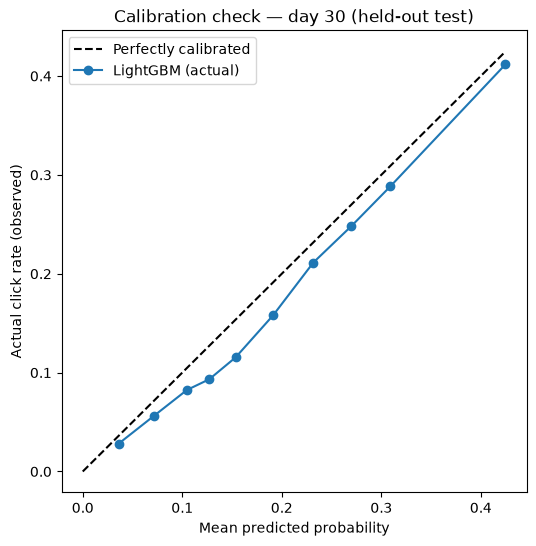

In [17]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test_lgb, proba_lgb_test)
print(f'LightGBM on test day 30 — AUC: {roc_auc_score(y_test_lgb, proba_lgb_test):.4f}  '
      f'Log-loss: {log_loss(y_test_lgb, proba_lgb_test):.4f}  Brier score: {brier:.4f}')

frac_pos, mean_pred = calibration_curve(y_test_lgb, proba_lgb_test, n_bins=10, strategy='quantile')
print('\nCalibration bins (predicted vs. actual click rate):')
for p, a in zip(mean_pred, frac_pos):
    print(f'  predicted={p:.3f}  actual={a:.3f}  diff={a - p:+.3f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, mean_pred.max()], [0, mean_pred.max()], 'k--', label='Perfectly calibrated')
ax.plot(mean_pred, frac_pos, marker='o', label='LightGBM (actual)')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual click rate (observed)')
ax.set_title('Calibration check — day 30 (held-out test)')
ax.legend()
plt.show()

## Conclusions
- **LightGBM is the clear winner** on both AUC and log-loss, with only a modest
  train-test AUC gap thanks to tuned regularization and early stopping — not overfit.
- **Logistic Regression is very stable** (train/val/test nearly identical, sometimes
  test even edges out train) but capacity-limited — a linear model can't capture the
  same interactions, so it plateaus at a lower ceiling regardless of `C`.
- Frequency encoding of high-cardinality IDs (`site_id`, `device_ip`, etc.) and the
  time-based split were the two biggest contributors to a believable, generalizable
  result versus the small-sample random-split demo in `eda.ipynb`.
- **Target encoding was tested and not adopted**: it edged out frequency encoding on both
  test AUC and log-loss, but nearly doubled the train-test AUC gap (0.027 → 0.047) for a
  small gain, and cost ~9 extra minutes of 5-fold cross-fitting per run. Given the goal was
  a stable, non-overfit model, frequency encoding remains the better trade-off — but this
  result is worth keeping as an honest "we tried it, here's why we didn't ship it" data
  point for the presentation.
- **Calibration is imperfect**: the model over-predicts click probability at every level
  (Brier score 0.1271), worst in the 10-20% predicted range (predicts ~15-19%, actual
  ~9-16%). AUC and log-loss both stay fine because ranking is unaffected — but raw
  probabilities aren't trustworthy for anything that uses the number directly (e.g. pricing
  at predicted-CTR × value). Fine for ranking/placement decisions; would need recalibration
  (e.g. Platt scaling or isotonic regression) before using the probabilities for pricing.

## Next steps
- If pursuing target encoding further despite the overfitting cost, stronger smoothing or
  a shrinkage-tuned prior might narrow the gap while keeping most of the AUC/log-loss gain.
- Recalibrate (Platt scaling / isotonic regression) if these probabilities are ever used
  for pricing rather than just ranking impressions.